# Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

from random import random
from datasets import load_dataset

from collections import Counter

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Week 6

## Encoder Decoder

### Question: Basically, What is the Encoder-Decoder Architetcture? 

The encoder-decoder architecture is a neural network framework used for sequence-to-sequence tasks, such as machine translation. It consists of two main components:

- **Encoder**: This part of the model processes the input sequence (e.g., a sentence in the source language) word by word using a Recurrent Neural Network (RNN), typically an LSTM or GRU. It transforms the entire input into a fixed-size vector representation (also called a context vector or hidden state), which is meant to capture the meaning of the full sentence.

- **Decoder**: This component takes the fixed-size vector produced by the encoder and generates the output sequence (e.g., a translated sentence) one word at a time. The decoder is also typically an RNN and is initialized with the encoder’s final hidden state. At each step, it uses the previously generated word and its current hidden state to predict the next word in the output.

The entire system is trained end-to-end, meaning that all parameters of both the encoder and decoder are optimized together to improve translation quality. One major advantage of this approach is its simplicity compared to traditional Statistical Machine Translation, which requires multiple separate components like alignment and phrase extraction.

However, a key limitation of this architecture is the fixed-size bottleneck between the encoder and decoder, which can lead to poor performance on long or complex sentences.

### Coded Example

For this notebook, I'll be using a German-English dataset

#### DataSet

In [4]:
# Load English to German translation dataset
dataset = load_dataset("opus_books", "de-en")

# Check available splits
print(dataset)

# Preview a sample
sample = dataset['train'][10]
print("German (source):", sample['translation']['de'])
print("English (target):", sample['translation']['en'])

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 51467
    })
})
German (source): »Jane, ich liebe weder Spitzfindigkeiten noch Fragen; außerdem ist es gradezu widerlich, wenn ein Kind ältere Leute in dieser Weise zur Rede stellt.
English (target): "Jane, I don't like cavillers or questioners; besides, there is something truly forbidding in a child taking up her elders in that manner.


In [5]:
# Take a small sample for prototyping
train_data = dataset['train'].select(range(1000))

# Extract sentence pairs
sentence_pairs = [(ex['translation']['de'], ex['translation']['en']) for ex in train_data]

#### Vocab Builder

Convert words into numbers that neural networks can understand, we build a vocabulary, but tokenizing the sentences by splitting on whitespace and converting to lowercase.

- $<pad>$ padding token
- $<sos>$ start of sentence
- $<eos>$ end of sentence
- $<unk>$ unknown word

Each word in the vocabulary is mapped to a unique integer ID.

In [6]:
# Basic tokenizer (split by space)
def tokenize(text):
    return text.lower().strip().split()

# Special tokens
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"
UNK = "<unk>"

def build_vocab(sentences, max_size=10000):
    counter = Counter()
    for sent in sentences:
        tokens = tokenize(sent)
        counter.update(tokens)
    most_common = counter.most_common(max_size - 4)
    vocab = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
    for i, (word, _) in enumerate(most_common, start=4):
        vocab[word] = i
    return vocab

# Build German (source) and English (target) vocabularies
src_vocab = build_vocab([pair[0] for pair in sentence_pairs])
tgt_vocab = build_vocab([pair[1] for pair in sentence_pairs])

# Reverse dicts
src_idx2word = {i: w for w, i in src_vocab.items()}
tgt_idx2word = {i: w for w, i in tgt_vocab.items()}

#### Sentece to Tensor

In [7]:
def numericalize(sentence, vocab):
    return [vocab.get(word, vocab[UNK]) for word in tokenize(sentence)]

def tensorize_pair(src_sent, tgt_sent, src_vocab, tgt_vocab):
    src_ids = numericalize(src_sent, src_vocab)
    tgt_ids = [tgt_vocab[SOS]] + numericalize(tgt_sent, tgt_vocab) + [tgt_vocab[EOS]]
    return torch.tensor(src_ids), torch.tensor(tgt_ids)


#### Model Definitions

We define two PyTorch models:

**Encoder**:

- Embeds each source word using an embedding layer.
- Feeds the embedded sequence into a GRU (a type of RNN).
- Returns the final hidden state, which summarizes the entire source sentence.

**Decoder**:

- Embeds each previously generated target word.
- Uses a GRU to generate the next hidden state and output.
- Passes the hidden state through a linear layer to predict the next word in the target sequence.

Both encoder and decoder use GRU layers for simplicity, but they could be replaced with LSTMs if better long-term memory is needed.

In [8]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden  # Pass only final hidden state

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embedding(tgt)
        output, hidden = self.rnn(embedded, hidden)
        output = self.fc(output)
        return output, hidden


#### Training The Model

In [57]:
# Hyperparameters
EMBED_SIZE = 256
HIDDEN_SIZE = 512
BATCH_SIZE = 1  # small for now
NUM_EPOCHS = 25
TEACHER_FORCING_RATIO = 0.5

# Instantiate models
encoder = Encoder(len(src_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# Training loop
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for src_sent, tgt_sent in sentence_pairs[:100]:  # use only a subset
        encoder.train()
        decoder.train()

        src_tensor, tgt_tensor = tensorize_pair(src_sent, tgt_sent, src_vocab, tgt_vocab)
        src_tensor = src_tensor.unsqueeze(0).to(device)
        tgt_tensor = tgt_tensor.unsqueeze(0).to(device)

        # Reset gradients
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        # Encode source
        encoder_hidden = encoder(src_tensor)

        # Initialize decoder input as SOS
        decoder_input = torch.tensor([[tgt_vocab["<sos>"]]], device=device)
        decoder_hidden = encoder_hidden

        loss = 0
        tgt_len = tgt_tensor.size(1)

        for t in range(1, tgt_len):
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            output = output.squeeze(1)
            loss += criterion(output, tgt_tensor[:, t])

            # Teacher forcing
            teacher_force = random() < TEACHER_FORCING_RATIO
            top1 = output.argmax(1).unsqueeze(1)
            decoder_input = tgt_tensor[:, t].unsqueeze(1) if teacher_force else top1

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        total_loss += loss.item() / tgt_len

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 697.5082
Epoch 2, Loss: 545.4065
Epoch 3, Loss: 479.0619
Epoch 4, Loss: 409.4306
Epoch 5, Loss: 339.6052
Epoch 6, Loss: 265.1289
Epoch 7, Loss: 191.7358
Epoch 8, Loss: 134.7811
Epoch 9, Loss: 100.9072
Epoch 10, Loss: 79.8619
Epoch 11, Loss: 48.0301
Epoch 12, Loss: 36.5519
Epoch 13, Loss: 23.2518
Epoch 14, Loss: 12.7581
Epoch 15, Loss: 7.5142
Epoch 16, Loss: 5.0984
Epoch 17, Loss: 4.1913
Epoch 18, Loss: 3.8709
Epoch 19, Loss: 3.2910
Epoch 20, Loss: 1.8511
Epoch 21, Loss: 1.5525
Epoch 22, Loss: 1.3730
Epoch 23, Loss: 1.2288
Epoch 24, Loss: 1.1070
Epoch 25, Loss: 1.0026


#### Quick Interence

In [28]:
def translate(sentence, max_len=20):
    encoder.eval()
    decoder.eval()

    src_tensor, _ = tensorize_pair(sentence, "", src_vocab, tgt_vocab)
    src_tensor = src_tensor.unsqueeze(0).to(device)
    encoder_hidden = encoder(src_tensor)

    decoder_input = torch.tensor([[tgt_vocab["<sos>"]]], device=device)
    decoder_hidden = encoder_hidden

    output_sentence = []

    for _ in range(max_len):
        output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        top1 = output.argmax(2)  # (batch, 1)
        word_idx = top1.item()
        if word_idx == tgt_vocab["<eos>"]:
            break
        output_sentence.append(tgt_idx2word.get(word_idx, "<unk>"))
        decoder_input = top1

    return " ".join(output_sentence)

# Try a test translation
test = 18
test_src = sentence_pairs[test][0]
print("German:", test_src, "\n")
print("Predicted English:", translate(test_src), "\n")
print("Reference English:", sentence_pairs[test][1])


German: Ich kehrte zu meinem Buche zurück – Bewicks Geschichte von Englands gefiederten Bewohnern; im allgemeinen kümmerte ich mich wenig um den gedruckten Text des Werkes, und doch waren da einige einleitende Seiten, welche ich, obgleich nur ein Kind, nicht gänzlich übergehen konnte. 

Predicted English: i returned to my book--bewick's history of british birds: the letterpress thereof i cared little for, generally speaking; and yet 

Reference English: I returned to my book--Bewick's History of British Birds: the letterpress thereof I cared little for, generally speaking; and yet there were certain introductory pages that, child as I was, I could not pass quite as a blank.


### Question: Why is machine translation considered a sequence-to-sequence task?

Machine translation is considered a sequence-to-sequence (seq2seq) task because it involves transforming one sequence of tokens (words in the source language) into another sequence of tokens (words in the target language), where both sequences can be of different lengths.

In this context:

- The input is a sequence of words in the source language (e.g., German).
- The output is a corresponding sequence of words in the target language (e.g., English).

This structure requires the model to:

- Understand the entire input sequence (its meaning, grammar, and context).
- Generate an output sequence that not only matches in meaning but also follows the correct grammar and structure of the target language.

Sequence-to-sequence models (like encoder-decoder architectures) are designed specifically for tasks like this, where the input and output are sequences of variable length, and the goal is to map one to the other in a meaningful way.

### Question: How does joint end-to-end training improve translation quality in NMT compared to SMT?

In NMT, joint end-to-end training means that all parts of the model—embedding layers, encoder, decoder, and output layers—are trained together to directly optimize translation quality.

**This improves over SMT, where components like alignment, phrase extraction, and language modeling are trained separately and heuristically combined. In SMT, improving one component doesn't guarantee better overall performance.**

In contrast, end-to-end training in NMT ensures that all parameters are adjusted simultaneously with respect to the final translation objective, leading to more coherent and accurate translations.


### Question: How is a word represented and processed through the encoder at each time step?

At each time step in the encoder:

1. The input word is first converted into an integer index using the source vocabulary.
2. This index is transformed into a one-hot vector (optional step).
3. The one-hot vector is passed through an embedding layer to produce a dense, low-dimensional vector.
4. This word embedding is then input to a recurrent layer (e.g., GRU or LSTM), which combines it with the previous hidden state to produce a new hidden state.
5. The hidden state at each time step captures information about the current word and its context from previous words.


### Question: How does the decoder generate the target sentence one word at a time?

Let's map each step of word processing in the encoder to the code:

1. **Integer Index Lookup**  
   The input `src` is a tensor of integer indices (already tokenized using the vocabulary).  
   → This is passed directly into `self.embedding(src)`.

2. **(Optional) One-Hot Encoding**  
   In our model, we skip one-hot encoding and go straight to dense embeddings using `nn.Embedding`.  
   → So this step is implicitly replaced by the embedding layer.

3. **Word Embedding**  
   `self.embedding(src)` converts each word index into a dense vector of size `embed_size`.  
   → `embedded = self.embedding(src)` returns a tensor of shape `(batch_size, seq_len, embed_size)`.

4. **Recurrent Step (GRU)**  
   The embeddings are passed through a GRU, which processes them sequentially and outputs hidden states.  
   → `outputs, hidden = self.rnn(embedded)`  
   - `outputs` contains the hidden state at every time step.  
   - `hidden` is the final hidden state, summarizing the entire input sequence.

5. **Final Hidden State**  
   The final hidden state (`hidden`) is returned. This vector will be used to initialize the decoder.  
   → `return hidden`

In summary, the encoder transforms a sequence of word indices into a **final context vector** using embeddings and a GRU.


In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return hidden  # Pass only final hidden state

### Question: Why do longer source sentences degrade the performance of the fixed-size representation in basic NMT models?

In basic NMT models using the encoder-decoder architecture, the entire source sentence is compressed into a single fixed-size vector (the final hidden state of the encoder). 

As the source sentence gets longer:
- More information needs to be stored in the same limited space.
- Important details may be lost due to compression.
- The model may struggle to capture long-range dependencies or nuanced context.

This bottleneck leads to degraded performance, especially for long or complex sentences, because the decoder has limited access to the full richness of the source sentence.


German sentence: Source: http://www.zeno.org - Contumax GmbH & Co. KG 

Context vector shape: torch.Size([512])
First 10 values of the vector: [-0.37785628  0.5788089  -0.98047227 -0.31963187 -0.83068585 -0.9741415
 -0.83739775 -0.9906602   0.99892884  0.26801273]


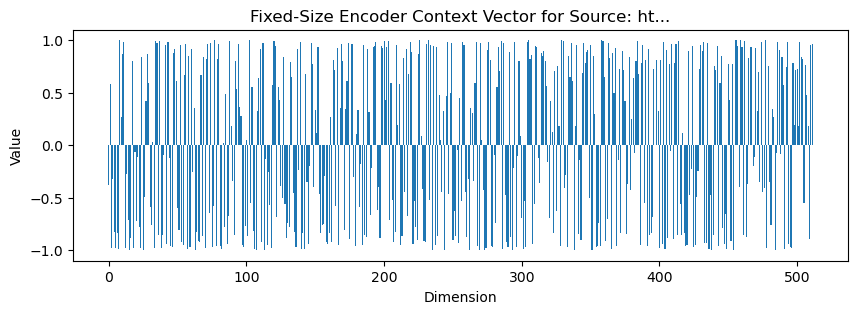

In [37]:
# Choose a sample sentence from the dataset
sample_de = sentence_pairs[0][0]

print("German sentence:", sample_de, "\n")

# Tokenize and convert to tensor
src_tensor, _ = tensorize_pair(sample_de, "", src_vocab, tgt_vocab)
src_tensor = src_tensor.unsqueeze(0).to(device)

# Get encoder output
with torch.no_grad():
    context_vector = encoder(src_tensor)  # shape: (1, 1, hidden_size)
    context_vector = context_vector.squeeze()  # shape: (hidden_size,)

# Show size and contents
print("Context vector shape:", context_vector.shape)
print("First 10 values of the vector:", context_vector[:10].cpu().numpy())

# Optional: visualize the vector as a bar plot
plt.figure(figsize=(10, 3))
plt.bar(range(len(context_vector)), context_vector.cpu().numpy())
plt.title(f"Fixed-Size Encoder Context Vector for {sample_de[0:10]}...")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.show()


German sentence: Ich kehrte zu meinem Buche zurück – Bewicks Geschichte von Englands gefiederten Bewohnern; im allgemeinen kümmerte ich mich wenig um den gedruckten Text des Werkes, und doch waren da einige einleitende Seiten, welche ich, obgleich nur ein Kind, nicht gänzlich übergehen konnte. 

Context vector shape: torch.Size([512])
First 10 values of the vector: [ 0.977923   -0.98720586 -0.65331906  0.9900434  -0.5172715   0.96906686
  0.30939084 -0.98889154  0.8186917  -0.07514954]


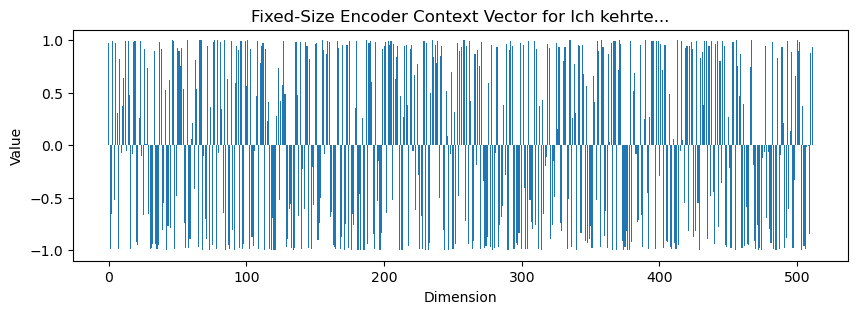

In [35]:
sample_de = sentence_pairs[test][0]

print("German sentence:", sample_de, "\n")

# Tokenize and convert to tensor
src_tensor, _ = tensorize_pair(sample_de, "", src_vocab, tgt_vocab)
src_tensor = src_tensor.unsqueeze(0).to(device)

# Get encoder output
with torch.no_grad():
    context_vector = encoder(src_tensor)  # shape: (1, 1, hidden_size)
    context_vector = context_vector.squeeze()  # shape: (hidden_size,)

# Show size and contents
print("Context vector shape:", context_vector.shape)
print("First 10 values of the vector:", context_vector[:10].cpu().numpy())

# Optional: visualize the vector as a bar plot
plt.figure(figsize=(10, 3))
plt.bar(range(len(context_vector)), context_vector.cpu().numpy())
plt.title(f"Fixed-Size Encoder Context Vector for {sample_de[0:10]}...")
plt.xlabel("Dimension")
plt.ylabel("Value")
plt.show()


### Question: Oh....so if a sentence is small, we just padd it out with spaces?

No, we don't "pad with spaces" to fill out the vector. Instead, the encoder always produces a **fixed-length hidden state** because the **hidden size** of the RNN (e.g., 512) is predetermined.

What happens is:

- For **short sentences**, the encoder processes fewer time steps.
  - The final hidden state is still of size 512 (or whatever you set), but it only reflects a small amount of content.
  - This means the context vector may be **under-utilized** — much of its capacity is unused or carries low information.

- For **long sentences**, the encoder has to compress a lot more information into the **same fixed-size vector**.
  - This can lead to **information loss**, as there's not enough space to encode all the nuances of the long sentence.

So the vector is always the same size — it doesn’t get padded or resized — but **how much it contains** (and how much it has to represent) changes based on the input length.


### Question: Given a very long sentence, how do we encode it in a fixed-sized vector? 

When given a very long sentence, a basic encoder (e.g., a GRU or LSTM) still produces a fixed-size context vector by **iteratively updating a hidden state** as it reads each word, one at a time.

Here's how it works:

1. The encoder starts with an initial hidden state (usually zeros).
2. It reads each word in the sentence in order, updating the hidden state at every step.
3. After processing the final word, it outputs the **final hidden state** as the context vector.
   - This vector has a fixed size (e.g., 512 dimensions), no matter how long the sentence is.
   - It is supposed to summarize all relevant information from the entire sequence.

For a long sentence, this process becomes challenging:
- The model must **compress a lot of information** into a single hidden state.
- Earlier inputs may get **"forgotten"** due to the limits of RNN memory.
- Subtle or long-range dependencies may not be well preserved.

So technically, the long sentence is encoded just like a short one: **step-by-step into a final hidden state**. The problem is that this fixed-size state can't scale to fit all the details in longer inputs.

This limitation is one of the key motivations for adding **attention mechanisms**, which we'll get to soon :D


### Question: What heuristics were attempted to improve translation quality for longer sentences, and why did they fall short?

One heuristic used to improve translation quality for longer sentences was to **reverse the order of the source sentence** before feeding it into the encoder.

The idea was that reversing might bring the words that are most relevant to the beginning of the target sentence closer to the final hidden state of the encoder, making them easier for the decoder to access.

However, this approach only provided **minor improvements** and failed to solve the core issue:
- The model still relied on a **single fixed-size vector** to encode all information, regardless of sentence length.
- This limited the model’s ability to capture long-range dependencies or detailed context in long sentences.

Ultimately, these heuristics fell short because they did not fundamentally address the **bottleneck** in the encoder-decoder architecture.


German sentence: Ich kehrte zu meinem Buche zurück – Bewicks Geschichte von Englands gefiederten Bewohnern; im allgemeinen kümmerte ich mich wenig um den gedruckten Text des Werkes, und doch waren da einige einleitende Seiten, welche ich, obgleich nur ein Kind, nicht gänzlich übergehen konnte. 



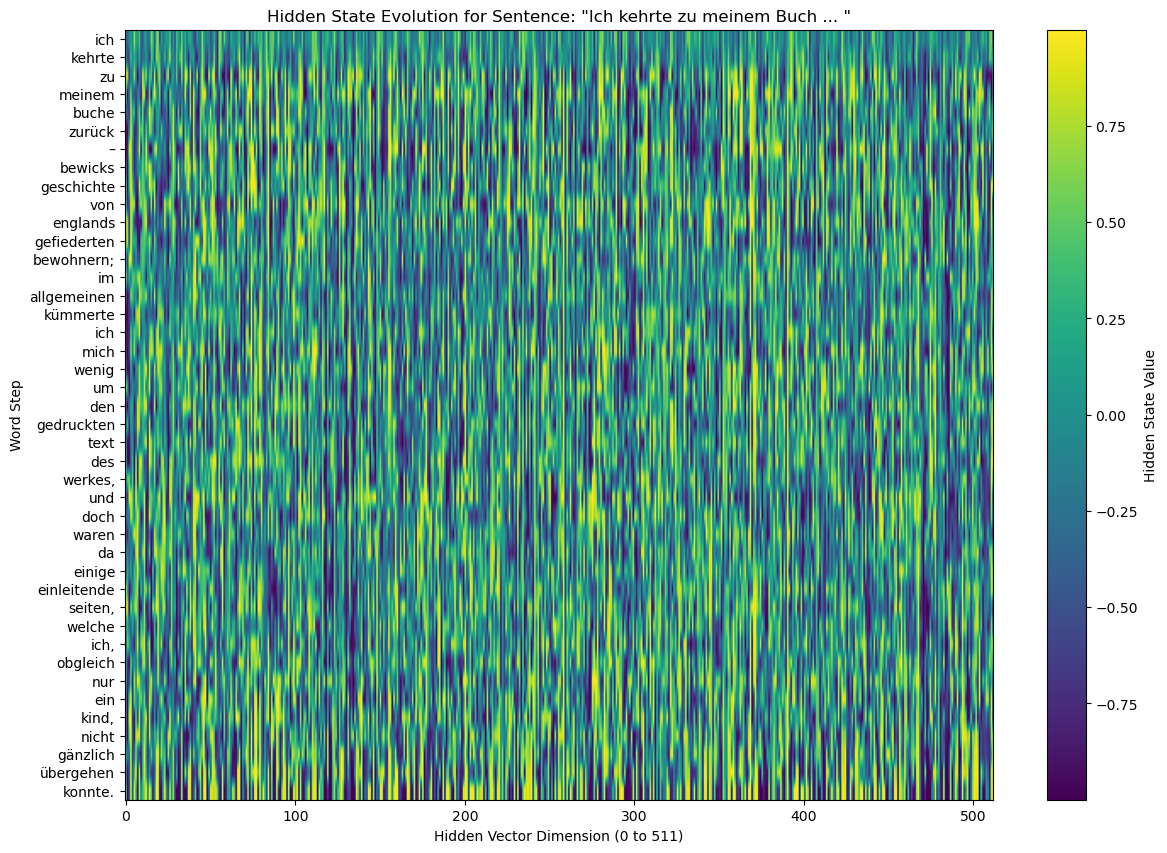

In [43]:
# Pick a short example sentence
test_sentence = sentence_pairs[test][0]
print("German sentence:", test_sentence, "\n")

# Tokenize and convert to tensor (no EOS/SOS for encoder input)
src_tokens = tokenize(test_sentence)
src_ids = [src_vocab.get(tok, src_vocab["<unk>"]) for tok in src_tokens]
src_tensor = torch.tensor(src_ids).unsqueeze(0).to(device)  # shape: (1, seq_len)

# Manually run step-by-step through encoder
hidden_states = []
embedded = encoder.embedding(src_tensor)  # shape: (1, seq_len, embed_size)

# Initialize hidden state
hidden = torch.zeros(1, 1, HIDDEN_SIZE).to(device)

# Pass one word at a time to GRU
for t in range(embedded.shape[1]):
    word_embed = embedded[:, t].unsqueeze(1)  # shape: (1, 1, embed_size)
    _, hidden = encoder.rnn(word_embed, hidden)
    hidden_states.append(hidden.squeeze().detach().cpu().numpy())

# Convert to 2D array: each row is a time step, each column a dimension
hidden_matrix = np.stack(hidden_states)  # shape: (time_steps, hidden_size)

# Plot using imshow
plt.figure(figsize=(14, 10))
plt.imshow(hidden_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Hidden State Value')
plt.title(f'Hidden State Evolution for Sentence: "{test_sentence[0:25]} ... "')
plt.xlabel("Hidden Vector Dimension (0 to 511)")
plt.ylabel("Word Step")
plt.yticks(ticks=range(len(src_tokens)), labels=src_tokens)
plt.show()


Each row in the graph represents the **hidden state of the encoder after processing a growing portion of the sentence**:

- **Row 1**: The hidden state after the **first word**.
- **Row 2**: The hidden state after the **first two words**.
- **Row 3**: After the **first three words**.
- ...
- **Final row**: The hidden state after the **entire sentence** has been read.

This hidden state is a **summary of everything the encoder has seen so far**. With each additional word, the state evolves to capture more of the sentence’s meaning.

The idea is that by the end:
- The final hidden state should contain all the relevant information from the full sentence.
- This final row (vector) is what gets passed to the decoder.

The color differences across rows help visualize how the encoder "remembers" and updates its internal representation with each new word.


## NMT Training

### Question: What parameters are trained in a neural machine translation system?

In a neural machine translation (NMT) system, the parameters that are trained are the **weights of the neural network**.

These include:
- The weights in the **embedding layers** (for both source and target vocabularies)
- The weights in the **encoder** (e.g., in GRU or LSTM layers)
- The weights in the **decoder** (including the recurrent layers and the output projection)
- The weights in the **output softmax layer** used to generate word probabilities

All of these weights are adjusted during training using backpropagation to minimize the translation error.


### Question: What is cross-entropy loss, and why is it commonly used in NMT training?

Cross-entropy loss is a measure of the difference between the **predicted probability distribution** over the vocabulary and the **true distribution**, which is a one-hot vector representing the correct word.

In neural machine translation, it's used to evaluate how well the model's predicted word probabilities match the actual target words at each time step.

Mathematically, for a single time step with vocabulary size $V$, cross-entropy loss is defined as:

$$
\text{Loss} = -\sum_{i=1}^{V} y_i \log(\hat{y}_i)
$$

Where:
- $y_i$ is the true probability of word $i$ (1 for the correct word, 0 for all others — i.e., one-hot encoding)
- $\hat{y}_i$ is the model's predicted probability for word $i$

Since only one $y_i$ is 1 (the correct word), this simplifies to:

$$
\text{Loss} = -\log(\hat{y}_{\text{correct}})
$$

This loss is computed for each word in the target sequence, then summed or averaged over all time steps.

**Why it's used in NMT**:
- It directly penalizes incorrect word predictions.
- It works well with softmax outputs from the decoder.
- It provides smooth gradients for optimization via backpropagation.

`criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])`



### Question: What is meant by an “epoch” in the context of neural network training?

An **epoch** refers to **one complete pass through the entire training dataset** during the training process of a neural network.

In other words, during one epoch, the model sees every training example exactly once and updates its weights based on that data (either per example, per batch, or after the full pass).

Training typically involves multiple epochs to allow the model to gradually improve and converge to better performance.


### Question: What are the key steps in the training loop of an encoder-decoder model?

The key steps in the training loop of an encoder-decoder model are:

1. **Forward Pass (Encoder)**  
   - The source sentence is passed through the encoder to produce a fixed-size context vector (final hidden state).

2. **Forward Pass (Decoder)**  
   - The decoder is initialized with the encoder's final hidden state.
   - At each time step, the decoder receives the previous target word (usually the ground-truth word during training) and produces a probability distribution over the vocabulary for the next word.

3. **Loss Calculation**  
   - Cross-entropy loss is computed by comparing the predicted word probabilities with the actual target words.

4. **Backward Pass (Backpropagation)**  
   - The error is backpropagated through the decoder and encoder to compute gradients of the loss with respect to all weights.

5. **Weight Update**  
   - Gradients are used to update the model’s weights using an optimization algorithm like SGD or Adam.

6. **Repeat**  
   - These steps are repeated for each training example (or mini-batch) across multiple epochs until the model converges.


### Question: How is the training sequence of an encoder-decoder model different from a standard (non-sequential) neural network training loop?

The key difference lies in the **sequential and conditional nature** of the encoder-decoder architecture:

1. **Sequential Dependencies**  
   - Unlike feedforward networks that process fixed-size inputs all at once, encoder-decoder models handle **variable-length sequences**, where each output depends on the previous ones.
   - The decoder generates each word **one at a time**, conditioned on previous target words and the encoded source context.

2. **Two-Part Model**  
   - The training loop includes two interdependent models:
     - The **encoder**, which processes the input sequence.
     - The **decoder**, which generates the output sequence, one token at a time.
   - Their computations are **chained together**, rather than being a single forward pass.

3. **Teacher Forcing**  
   - During training, the decoder receives the **ground-truth previous word** as input (teacher forcing), which differs from standard models where inputs are fixed and do not evolve based on output.

4. **Time-Step-Wise Loss**  
   - Loss is computed across **multiple time steps**, one for each predicted token in the output sequence, and must be summed or averaged across the entire target sentence.

5. **Exposure Bias Risk**  
   - The model is trained with correct inputs but used at inference with its own predictions — this gap doesn’t exist in standard models and can introduce **exposure bias**.

These characteristics make encoder-decoder training more complex and more sensitive to sequence structure and temporal dependencies.


### Question: Why can't we try all possible weight combinations to minimize error in NMT models?

We can't try all possible weight combinations in NMT models because the **number of weights is extremely large**, often in the **millions or more**.

The space of all possible combinations of weights forms a **high-dimensional, continuous search space**, making brute-force evaluation computationally infeasible.

Instead of exhaustively trying every combination, we use **gradient-based optimization** (like gradient descent), which efficiently adjusts the weights by:
- Computing how a small change in each weight affects the loss (via gradients)
- Moving the weights in the direction that reduces the loss

This allows the model to find good (though not necessarily optimal) weights much faster and with far less computation.


### Question: What is mini-batch gradient descent, and why is it preferred over full-batch or single-sample training?

Mini-batch gradient descent is a training strategy where the model updates its weights after computing the gradients on a **small subset of the training data**, called a **mini-batch** (typically 32–256 samples).

This method balances two extremes:

- **Full-batch gradient descent**  
  Uses the entire dataset to compute gradients before each update.  
  ✅ Stable gradients  
  ❌ Very slow and memory-intensive for large datasets

- **Stochastic gradient descent (SGD)**  
  Updates weights after each individual example.  
  ✅ Fast updates  
  ❌ Noisy gradients, may lead to unstable convergence

**Why mini-batching is preferred:**
- It provides a compromise between speed and stability.
- Gradients are averaged over multiple examples, reducing noise compared to SGD.
- It's more computationally efficient than full-batch, especially when using GPU parallelism.
- Allows the use of optimized libraries and hardware acceleration for matrix operations.

Overall, mini-batching helps training converge faster and more reliably in practice.


#### Question: In our example from before, did we use mini-batching?

Nope.

### Pyton Mini-Batch Example

/tmp/ipykernel_4892/2181157964.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  src_batch = [torch.tensor(seq) for seq in src_batch]
/tmp/ipykernel_4892/2181157964.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tgt_batch = [torch.tensor(seq) for seq in tgt_batch]


Epoch 1, Loss: 7.3701
Epoch 2, Loss: 6.6465
Epoch 3, Loss: 6.4756
Epoch 4, Loss: 6.2559
Epoch 5, Loss: 6.0377
Epoch 6, Loss: 5.8116
Epoch 7, Loss: 5.5714
Epoch 8, Loss: 5.3108
Epoch 9, Loss: 4.9564
Epoch 10, Loss: 4.6584


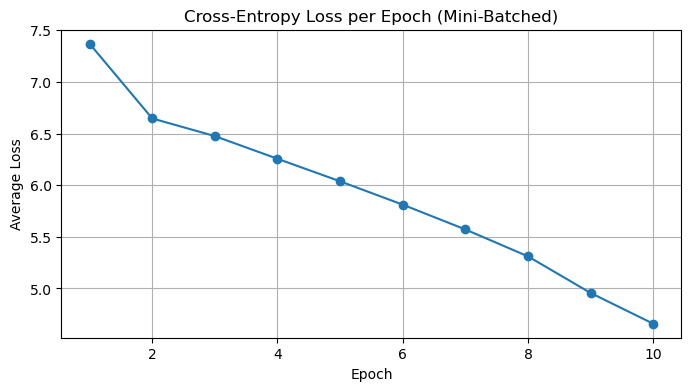

In [47]:
# Parameters
BATCH_SIZE = 16
NUM_EPOCHS = 10

# Custom Dataset
class TranslationDataset(Dataset):
    def __init__(self, sentence_pairs):
        self.data = sentence_pairs

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_sent, tgt_sent = self.data[idx]
        src_tensor, tgt_tensor = tensorize_pair(src_sent, tgt_sent, src_vocab, tgt_vocab)
        return src_tensor, tgt_tensor

# Collate function for padding batches
def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)

    src_batch = [torch.tensor(seq) for seq in src_batch]
    tgt_batch = [torch.tensor(seq) for seq in tgt_batch]

    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=src_vocab["<pad>"])
    tgt_padded = pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_vocab["<pad>"])

    return src_padded.to(device), tgt_padded.to(device)

# Create DataLoader
train_dataset = TranslationDataset(sentence_pairs[:1000])
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

encoder = Encoder(len(src_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
encoder_optimizer = torch.optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=0.001)

loss_history = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for src_batch, tgt_batch in train_loader:
        encoder.train()
        decoder.train()

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        # Encode
        encoder_hidden = encoder(src_batch)  # (1, batch, hidden)

        # Prepare decoder inputs
        decoder_input = torch.full((src_batch.size(0), 1), tgt_vocab["<sos>"], dtype=torch.long).to(device)
        decoder_hidden = encoder_hidden

        loss = 0
        tgt_len = tgt_batch.size(1)

        for t in range(1, tgt_len):
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            output = output.squeeze(1)  # (batch, vocab_size)

            # Only calculate loss for non-padding positions
            loss += criterion(output, tgt_batch[:, t])

            teacher_force = random() < TEACHER_FORCING_RATIO
            top1 = output.argmax(1).unsqueeze(1)  # (batch, 1)

            next_input = tgt_batch[:, t].unsqueeze(1) if teacher_force else top1
            decoder_input = next_input

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item() / tgt_len

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), loss_history, marker='o')
plt.title("Cross-Entropy Loss per Epoch (Mini-Batched)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()


### Question: How do optimizers like Adam improve upon basic gradient descent?

Optimizers like **Adam** improve upon basic gradient descent by adapting the learning rate for **each parameter individually** and incorporating momentum-like behavior.

Key improvements of Adam:

1. **Adaptive Learning Rates**  
   - Adam adjusts the learning rate for each weight based on the **history of gradients**, allowing faster convergence and better handling of sparse updates.

2. **Momentum**  
   - It uses an **exponentially weighted moving average** of past gradients (like momentum), helping it smooth out noisy updates and accelerate in relevant directions.

3. **Bias Correction**  
   - Adam includes corrections to account for the initialization of moving averages, which makes early training steps more accurate.

Mathematically, Adam combines ideas from both **AdaGrad** and **RMSProp**:

- First moment estimate (mean of gradients):  
  $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$

- Second moment estimate (uncentered variance):  
  $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$

- Bias-corrected updates:  
  $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$  
  $\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$

- Final update rule:  
  $w_t = w_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

Because of these mechanisms, Adam often converges **faster and more reliably** than vanilla gradient descent, especially for deep networks like encoder-decoder models.


### Question: What is exposure bias in NMT training, and when does it become a problem?

**Exposure bias** is a problem that arises in neural machine translation (NMT) when the model behaves differently during training and inference.

**During Training**:
- The decoder is trained using **teacher forcing**, where it always receives the **correct previous word** (from the ground truth) as input at each time step.

**During Inference (Translation)**:
- The decoder must use its **own predicted word** from the previous time step, not the ground truth.

**Why this is a problem**:
- The model is **never exposed during training** to its own mistakes.
- If it makes an incorrect prediction during inference, that incorrect word becomes the next input — and the errors can **accumulate**, leading to poor translations.
- This mismatch between training and inference is what we call **exposure bias**.

**When does it become a problem?**
- Especially in long sequences, where one early mistake can derail the entire output.
- In domains with complex syntax or low redundancy, where precise word choices are critical.

Solutions include:
- Scheduled sampling
- Reinforcement learning-based training
- Using sequence-level training objectives (like BLEU)


### Question: How are the weights updated during training? 

**Gradient Descent Weight Update**

In each training step, we compute the **gradient of the loss** with respect to each weight using backpropagation, then **subtract the gradient** (scaled by a learning rate) from the current weight value.

$$
w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial \text{Loss}}{\partial w}
$$

Where:
- $w$ is a model weight
- $\eta$ is the learning rate (e.g., 0.001)
- $\frac{\partial \text{Loss}}{\partial w}$ is the gradient of the loss with respect to that weight

If you're doing it manually:
```python
with torch.no_grad():
    for param in model.parameters():
        param -= learning_rate * param.grad
```
But normally, PyTorch handles this with an optimizer like Adam or SGD


## NMT Decoding

### Question: The search for the best hypothesis in an encoder-decoder model is performed by the ____?

decoder.

### Question: What is the key difference between greedy search and beam search in NMT decoding?

The key difference between greedy search and beam search in NMT decoding lies in how many hypotheses (partial translations) they consider at each time step:

- **Greedy search** selects the single most probable word at each step and proceeds with that choice only. It always follows one path and does not backtrack or reconsider earlier decisions.

- **Beam search**, on the other hand, keeps track of the top *N* most probable partial translations (where *N* is the beam size) at each step. It expands all of them and then prunes back to the best *N*, allowing it to explore multiple possible paths in parallel.

As a result, beam search is more computationally expensive but can produce higher-quality translations by avoiding early commitment to suboptimal words.


### Question: In the Decoder example from above, which did I use 

```
# Hyperparameters
EMBED_SIZE = 256
HIDDEN_SIZE = 512
BATCH_SIZE = 1  # small for now
NUM_EPOCHS = 25
TEACHER_FORCING_RATIO = 0.5

# Instantiate models
encoder = Encoder(len(src_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)
decoder = Decoder(len(tgt_vocab), EMBED_SIZE, HIDDEN_SIZE).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.001)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=0.001)

# Training loop
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for src_sent, tgt_sent in sentence_pairs[:100]:  # use only a subset
        encoder.train()
        decoder.train()

        src_tensor, tgt_tensor = tensorize_pair(src_sent, tgt_sent, src_vocab, tgt_vocab)
        src_tensor = src_tensor.unsqueeze(0).to(device)
        tgt_tensor = tgt_tensor.unsqueeze(0).to(device)

        # Reset gradients
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        # Encode source
        encoder_hidden = encoder(src_tensor)

        # Initialize decoder input as SOS
        decoder_input = torch.tensor([[tgt_vocab["<sos>"]]], device=device)
        decoder_hidden = encoder_hidden

        loss = 0
        tgt_len = tgt_tensor.size(1)

        for t in range(1, tgt_len):
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            output = output.squeeze(1)
            loss += criterion(output, tgt_tensor[:, t])

            # Teacher forcing
            teacher_force = random() < TEACHER_FORCING_RATIO
            top1 = output.argmax(1).unsqueeze(1) #<--- here it is
            decoder_input = tgt_tensor[:, t].unsqueeze(1) if teacher_force else top1

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        total_loss += loss.item() / tgt_len

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
```

Greedy search is used during training or inference to generate a translation by always selecting the **most probable next word** at each time step.

In our training loop, this line implements greedy decoding:

```
top1 = output.argmax(1).unsqueeze(1)
```

Here’s what happens:

- output contains predicted probabilities over the target vocabulary.
- argmax(1) selects the word with the highest probability.
- This word becomes the decoder's input at the next time step (if we are not using teacher forcing).

So the decoder builds the output sequence one word at a time by greedily choosing the highest-probability word, without considering how this choice might affect future predictions.

This approach is simple and fast, but it may not always produce the best overall sentence because it makes locally optimal decisions without exploring alternatives.

### Question: How would I implement N-beam search?

Beam search is not typically used in training, but in inference/decoding, where you don't have access to ground-truth target sentences.

That said, if you want to try beam search in a separate inference function, here’s the right place to implement it:

### Beam Search Example

In [61]:
def beam_search_decode(encoder, decoder, src_sentence, src_vocab, tgt_vocab, beam_width=5, max_len=50):
    encoder.eval()
    decoder.eval()

    # Convert source sentence to tensor
    src_tensor, _ = tensorize_pair(src_sentence, "", src_vocab, tgt_vocab)
    src_tensor = src_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_hidden = encoder(src_tensor)

        beams = [([tgt_vocab["<sos>"]], 0.0, encoder_hidden)]

        for _ in range(max_len):
            new_beams = []
            for seq, score, hidden in beams:
                if seq[-1] == tgt_vocab["<eos>"]:
                    new_beams.append((seq, score, hidden))  # finished sequence
                    continue

                decoder_input = torch.tensor([[seq[-1]]], device=device)
                output, new_hidden = decoder(decoder_input, hidden)
                probs = torch.log_softmax(output.squeeze(1), dim=-1)

                topk_probs, topk_indices = torch.topk(probs, beam_width)

                for i in range(beam_width):
                    next_word = topk_indices[0][i].item()
                    next_score = score + topk_probs[0][i].item()
                    new_seq = seq + [next_word]
                    new_beams.append((new_seq, next_score, new_hidden))

            # Keep only the top beam_width hypotheses
            beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

            # Early stopping if all end in <eos>
            if all(seq[-1] == tgt_vocab["<eos>"] for seq, _, _ in beams):
                break

        # Return best sequence (strip <sos> and <eos>)
        best_seq = beams[0][0]
        inv_vocab = {v: k for k, v in tgt_vocab.items()}
        return [inv_vocab[idx] for idx in best_seq[1:-1]]

def translate_beam(src_sentence, beam_width=5):
    output_tokens = beam_search_decode(encoder, decoder, src_sentence, src_vocab, tgt_vocab, beam_width)
    return " ".join(output_tokens)

# Try a test translation using beam search
test = 250
test_src = sentence_pairs[test][0]
print("German:", test_src, "\n")
beam = 1
print(f"Predicted English ({beam}): {translate_beam(test_src, beam_width=beam)} \n")
beam = 5
print(f"Predicted English ({beam}): {translate_beam(test_src, beam_width=beam)} \n")

print("Reference English:", sentence_pairs[test][1])


German: Haben Sie Schmerzen?« 

Predicted English (1): the breakfast- and i was to the red-room, and stand in there." 

Predicted English (5): we were parted: and i was the answer. 

Reference English: Have you any pain?"


### Question: Why might greedy search fail to produce the best overall translation, even if it selects the most probable word at each step?

Greedy search fails to produce the best overall translation because it makes **locally optimal decisions** at each step, choosing the most probable word without considering how that choice affects future steps.

This can lead to:
- Early choices that seem good short-term but make it **hard to complete the sentence meaningfully** later.
- Missing sequences that have **higher total probability** across the whole sentence but require less probable early words.

Example:
- Choosing word A now (probability = 0.9) leads to poor continuation.
- Choosing word B (probability = 0.7) leads to a much better full sentence.
- Greedy search will choose A, even if B leads to a better overall result.

In contrast, beam search keeps multiple hypotheses and can recover from suboptimal early choices by exploring alternatives.


### Question: What is the main goal of decoding in NMT?

The main goal of decoding in Neural Machine Translation (NMT) is to **generate the most probable target sentence** given a source sentence, according to the model's learned probability distribution.

Formally, the decoder aims to find the translation $\hat{y}$ that maximizes the conditional probability:

$$
\hat{y} = \arg\max_{y} P(y \mid x)
$$

Where:
- $x$ is the source sentence
- $y$ is a candidate translation
- $P(y \mid x)$ is the probability assigned by the NMT model

Because exhaustively searching all possible target sentences is computationally infeasible, heuristic algorithms like **greedy search** or **beam search** are used to approximate this goal.


### Question: What happens if the model never generates an <eos> token during decoding?

If the model never generates an `<eos>` (end-of-sentence) token during decoding, the translation process will not know when to stop and could continue generating words indefinitely.

To prevent this, decoding typically includes a **maximum output length** (e.g., 50 or 100 tokens). If `<eos>` is not generated within this limit, the decoding process is forcibly stopped.

Consequences of missing `<eos>`:
- The output may be **incomplete**, **rambling**, or **repetitive**.
- It can result in **invalid or incoherent translations**.
- It indicates that the model may not have learned proper sentence boundaries or confidence in stopping.

Good models are trained to generate `<eos>` at appropriate points, and its absence may signal issues with training data, loss function, or decoding strategy.


### Question: What is a model error in NMT decoding, and what causes it?

A model error in NMT decoding occurs when the model assigns a **higher probability to an incorrect or suboptimal translation** than to the correct one.

This means that, even with perfect search (e.g., exhaustive or beam search), the model would still generate a poor translation because it has learned a **flawed representation of language or translation mappings**.

Model errors are typically caused by:
- Inadequate or biased training data
- Insufficient model capacity or architecture limitations
- Poorly tuned hyperparameters
- Overfitting or underfitting during training

Improving model quality (e.g., better data, regularization, architecture changes) is required to reduce model errors.


### Question: What is a search error in NMT decoding, and how does it differ from a model error?

A search error in NMT decoding happens when the correct translation has a **higher probability** according to the model, but the **search algorithm fails to find it**.

This occurs because:
- The search space is too large to explore exhaustively
- Heuristic algorithms like greedy or beam search **prune away promising paths too early**
- The beam size is too small to capture the optimal sequence

In contrast, a **model error** means the model itself assigns low probability to the correct translation — even if it were found, it wouldn’t be selected.

**Key difference:**
- Model error = The model's probability distribution is wrong
- Search error = The model is correct, but the search fails to find the best path

Search errors can often be reduced by improving the decoding algorithm (e.g., increasing beam size), while model errors require improving the training process.


### Question: How can one reduce search errors during decoding?

Search errors during decoding can be reduced by improving the **search strategy** so that it is more likely to find high-probability translations according to the model.

Common methods include:

- **Increasing Beam Size**  
  A larger beam allows the decoder to explore more hypotheses at each step, reducing the chance of pruning away the best path too early.

- **Length Normalization**  
  Penalizing shorter or longer sequences by normalizing log-probabilities by sequence length can prevent biased pruning.

- **Diverse Beam Search**  
  Promotes diversity among beam candidates to avoid getting stuck in similar, suboptimal hypotheses.

- **Reranking with External Features**  
  Generate an N-best list of candidate translations and rerank them using additional features or models.

- **Coverage Penalties**  
  Penalize translations that under-translate or ignore parts of the source sentence, helping to improve alignment quality.

While these techniques help reduce **search errors**, they must be balanced with decoding speed and risk of overgeneration.


## Attention Based NMT

### Question: What is the main problem with using a fixed-size context vector in traditional encoder-decoder models?

The main problem with using a fixed-size context vector in traditional encoder-decoder models is that it creates a **bottleneck** for information flow between the encoder and decoder.

This vector must **compress all the information** from the entire source sentence—regardless of its length—into a single fixed-size representation.

As the source sentence becomes longer or more complex:
- Important details may be **lost or blurred**.
- The model may struggle to **generate accurate translations**.
- Performance tends to degrade

### Question: How does the attention mechanism help address the problem of long sentences in NMT?

The attention mechanism helps address the problem of long sentences in NMT by allowing the model to **dynamically focus on different parts of the source sentence** at each decoding step.

Instead of relying on a single fixed-size context vector, the model:
- Produces a **sequence of encoder representations**, one for each source word.
- Computes a **context vector** at each step as a **weighted sum** of these representations.
- Assigns **higher weights** to source words that are more relevant for generating the current target word.

This approach allows the model to:
- Access **full sentence information** without needing to compress it.
- Handle **long or complex sentences** more effectively.
- Adapt its focus as the translation progresses.


### Transformer Architecture in Pytorch

You might get cuda errors here since we have a lot in memory...just restart the notebook and add in the relevant parts. This is a very poor model, just here for reference. 

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import math, time, copy
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

from random import random
from datasets import load_dataset

from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load English to German translation dataset
dataset = load_dataset("opus_books", "de-en")

# Check available splits
print(dataset)

# Preview a sample
sample = dataset['train'][10]
print("German (source):", sample['translation']['de'])
print("English (target):", sample['translation']['en'])

# Take a small sample for prototyping
train_data = dataset['train'].select(range(1000))

# Extract sentence pairs
sentence_pairs = [(ex['translation']['de'], ex['translation']['en']) for ex in train_data]

# --- Tokenization & Vocab ---
def tokenize(s): return s.lower().split()

def build_vocab(sentences, min_freq=1):
    counter = Counter()
    for sent in sentences:
        counter.update(tokenize(sent))
    vocab = {"<pad>": 0, "<bos>": 1, "<eos>": 2, "<unk>": 3}
    for word, freq in counter.items():
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    inv_vocab = {v: k for k, v in vocab.items()}
    return vocab, inv_vocab

src_texts = [pair[0] for pair in sentence_pairs]
tgt_texts = [pair[1] for pair in sentence_pairs]

src_vocab, inv_src_vocab = build_vocab(src_texts)
tgt_vocab, inv_tgt_vocab = build_vocab(tgt_texts)
PAD_IDX, BOS_IDX, EOS_IDX = src_vocab["<pad>"], src_vocab["<bos>"], src_vocab["<eos>"]

def encode(sentence, vocab):
    return [vocab["<bos>"]] + [vocab.get(tok, vocab["<unk>"]) for tok in tokenize(sentence)] + [vocab["<eos>"]]

# --- Dataset ---
class Seq2SeqDataset(Dataset):
    def __init__(self, src_texts, tgt_texts):
        self.pairs = list(zip(src_texts, tgt_texts))

    def __getitem__(self, idx):
        src = torch.tensor(encode(self.pairs[idx][0], src_vocab))
        tgt = torch.tensor(encode(self.pairs[idx][1], tgt_vocab))
        return src, tgt

    def __len__(self):
        return len(self.pairs)

def collate(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch.to(device), tgt_batch.to(device)

train_data = Seq2SeqDataset(src_texts, tgt_texts)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True, collate_fn=collate)

# --- Positional Encoding ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(1)

    def forward(self, x):
        x = x + self.pe[:x.size(0)].to(x.device)
        return self.dropout(x)

# --- Transformer Model ---
class TransformerMT(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, nhead=4, num_layers=4):
        super().__init__()
        self.src_embed = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(d_model, nhead, num_layers, num_layers)
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.d_model = d_model

    def forward(self, src, tgt):
        src_mask = self.transformer.generate_square_subsequent_mask(src.size(0)).to(device)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt.size(0)).to(device)

        src_emb = self.pos_enc(self.src_embed(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_enc(self.tgt_embed(tgt) * math.sqrt(self.d_model))

        out = self.transformer(src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask)
        return self.fc_out(out)

model = TransformerMT(len(src_vocab), len(tgt_vocab)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# --- Training ---
def train_epoch():
    model.train()
    total_loss = 0
    for src, tgt in train_loader:
        tgt_input = tgt[:-1, :]
        tgt_y = tgt[1:, :].reshape(-1)

        optimizer.zero_grad()
        output = model(src, tgt_input)
        output = output.reshape(-1, output.shape[-1])
        loss = criterion(output, tgt_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

EPOCHS = 25
for epoch in range(EPOCHS):
    loss = train_epoch()
    print(f"Epoch {epoch+1} | Loss: {loss:.4f}")

# --- Translation (Greedy) ---
def translate(sentence, max_len=20):
    model.eval()
    src = torch.tensor(encode(sentence, src_vocab)).unsqueeze(1).to(device)
    memory = model.transformer.encoder(model.pos_enc(model.src_embed(src) * math.sqrt(model.d_model)))

    tgt = torch.tensor([[BOS_IDX]], device=device)
    for _ in range(max_len):
        tgt_emb = model.pos_enc(model.tgt_embed(tgt) * math.sqrt(model.d_model))
        tgt_mask = model.transformer.generate_square_subsequent_mask(tgt.size(0)).to(device)
        out = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        out = model.fc_out(out)
        next_token = out.argmax(-1)[-1, 0].item()
        tgt = torch.cat([tgt, torch.tensor([[next_token]], device=device)], dim=0)
        if next_token == tgt_vocab["<eos>"]:
            break
    return " ".join(inv_tgt_vocab[i] for i in tgt.squeeze().tolist()[1:-1])

# --- Try a Test Translation ---
idx = 18
print("German:   ", sentence_pairs[idx][0])
print("Reference:", sentence_pairs[idx][1])
print("Predicted:", translate(sentence_pairs[idx][0]))



DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 51467
    })
})
German (source): »Jane, ich liebe weder Spitzfindigkeiten noch Fragen; außerdem ist es gradezu widerlich, wenn ein Kind ältere Leute in dieser Weise zur Rede stellt.
English (target): "Jane, I don't like cavillers or questioners; besides, there is something truly forbidding in a child taking up her elders in that manner.


/home/mcruggs/anaconda3/envs/lit/lib/python3.10/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1 | Loss: 7.2572
Epoch 2 | Loss: 6.8968
Epoch 3 | Loss: 6.8628
Epoch 4 | Loss: 6.8498
Epoch 5 | Loss: 6.8427
Epoch 6 | Loss: 6.8344
Epoch 7 | Loss: 6.8288
Epoch 8 | Loss: 6.8326
Epoch 9 | Loss: 6.8253
Epoch 10 | Loss: 6.8201
Epoch 11 | Loss: 6.8189
Epoch 12 | Loss: 6.8226
Epoch 13 | Loss: 6.8184
Epoch 14 | Loss: 6.8130
Epoch 15 | Loss: 6.8065
Epoch 16 | Loss: 6.8088
Epoch 17 | Loss: 6.8062
Epoch 18 | Loss: 6.8015
Epoch 19 | Loss: 6.8015
Epoch 20 | Loss: 6.8011
Epoch 21 | Loss: 6.8017
Epoch 22 | Loss: 6.8014
Epoch 23 | Loss: 6.7993
Epoch 24 | Loss: 6.8026
Epoch 25 | Loss: 6.7947
German:    Ich kehrte zu meinem Buche zurück – Bewicks Geschichte von Englands gefiederten Bewohnern; im allgemeinen kümmerte ich mich wenig um den gedruckten Text des Werkes, und doch waren da einige einleitende Seiten, welche ich, obgleich nur ein Kind, nicht gänzlich übergehen konnte.
Reference: I returned to my book--Bewick's History of British Birds: the letterpress thereof I cared little for, general

### Question: How is the source sentence represented in the attention-based model?

In the attention-based model, the source sentence is represented as a **sequence of hidden states**, one for each word in the sentence.

These hidden states are generated by a **bidirectional RNN (e.g., Bi-GRU or Bi-LSTM)**:
- One RNN processes the sentence from **left to right**.
- Another processes it from **right to left**.
- The hidden states from both directions are **concatenated** at each position to form a **rich representation** that includes information from both the **past and future context**.

This results in a **set of vectors**, each encoding the meaning of a source word in its full sentence context, which the attention mechanism can later selectively focus on.
